In [12]:
# Cell 1 - Imports
# Run with a kernel that has pywt (e.g., the pointcloud_to_raster_cs kernel)
import numpy as np
import matplotlib.pyplot as plt
import h5py
import pywt

%matplotlib inline

Image: 1052 x 475
Ascending LOS: E=-0.686, U=0.718
Descending LOS: E=0.691, U=0.713
det(A) range: [-0.9853, -0.9839]
Pixels with |det(A)| < 0.1: 0


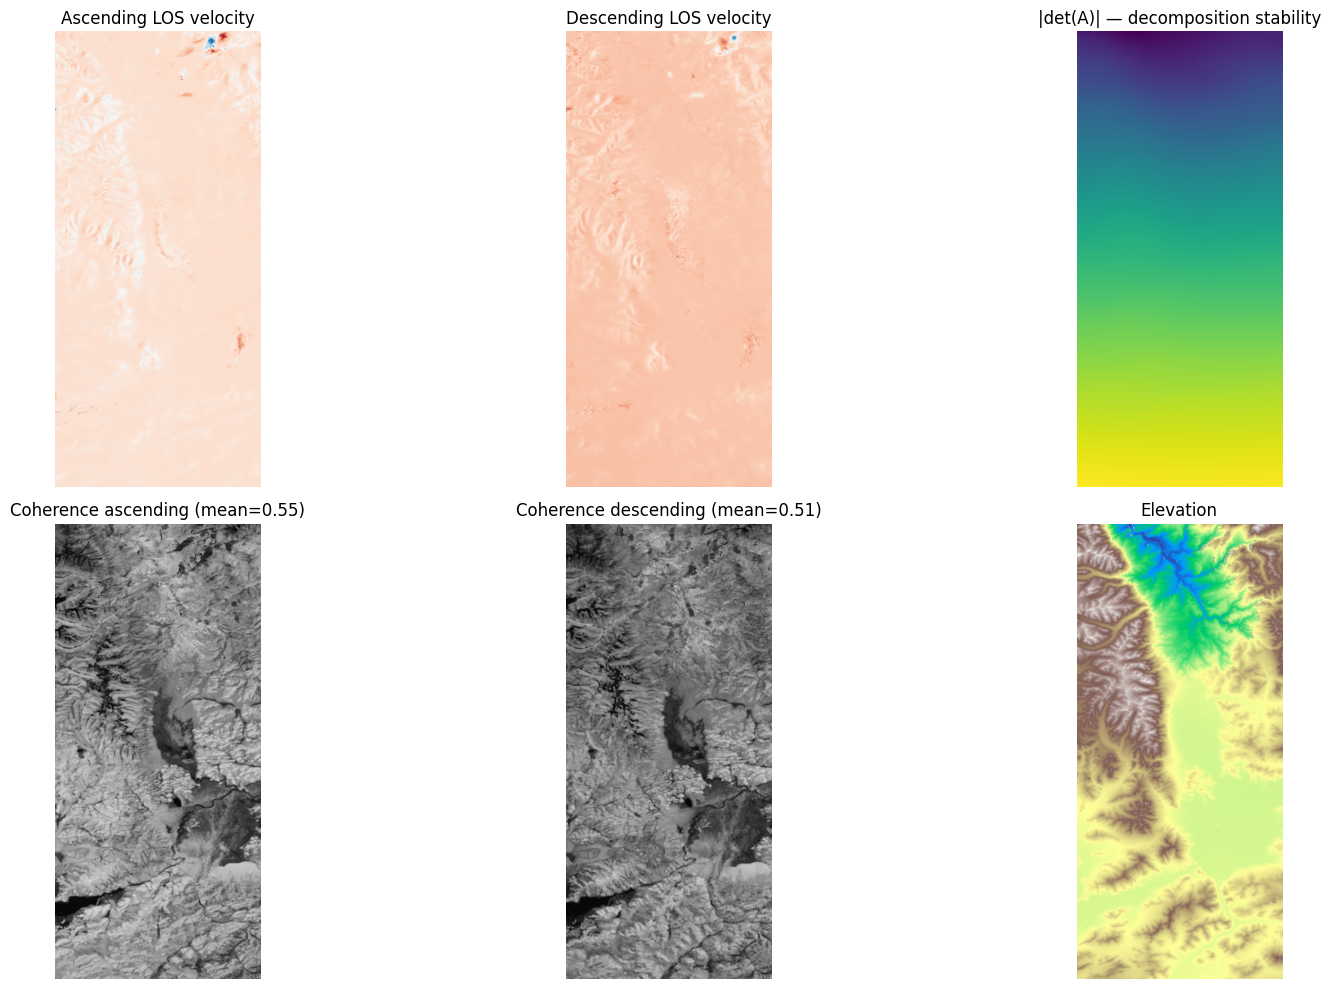

In [13]:
# Cell 2 - Load ascending + descending InSAR data
asc_path = '/Users/amasaryk/Downloads/Asc_cum_filt.h5'
desc_path = '/Users/amasaryk/Downloads/Descending_cum_filt.h5'

with h5py.File(asc_path, 'r') as f:
    vel_asc = f['vel'][:].astype(np.float32)
    coh_asc = f['coh_avg'][:].astype(np.float32)
    mask_asc = f['mask'][:]
    E_asc = f['E.geo'][:].astype(np.float32)
    N_asc = f['N.geo'][:].astype(np.float32)
    U_asc = f['U.geo'][:].astype(np.float32)
    hgt = f['hgt'][:].astype(np.float32)
    clat_a = float(f['corner_lat'][()])
    clon_a = float(f['corner_lon'][()])
    plat_a = float(f['post_lat'][()])
    plon_a = float(f['post_lon'][()])

with h5py.File(desc_path, 'r') as f:
    vel_desc = f['vel'][:].astype(np.float32)
    coh_desc = f['coh_avg'][:].astype(np.float32)
    mask_desc = f['mask'][:]
    E_desc = f['E.geo'][:].astype(np.float32)
    U_desc = f['U.geo'][:].astype(np.float32)
    clat_d = float(f['corner_lat'][()])
    clon_d = float(f['corner_lon'][()])

# Clean NaN
vel_asc = np.nan_to_num(vel_asc, nan=0.0)
vel_desc = np.nan_to_num(vel_desc, nan=0.0)
coh_asc = np.nan_to_num(coh_asc, nan=0.0)
coh_desc = np.nan_to_num(coh_desc, nan=0.0)

ny, nx = vel_asc.shape
print(f'Image: {ny} x {nx}')
print(f'Ascending LOS: E={np.nanmean(E_asc):.3f}, U={np.nanmean(U_asc):.3f}')
print(f'Descending LOS: E={np.nanmean(E_desc):.3f}, U={np.nanmean(U_desc):.3f}')

# det(A) for the naive decomposition
det_A = E_asc * U_desc - U_asc * E_desc
print(f'det(A) range: [{det_A.min():.4f}, {det_A.max():.4f}]')
print(f'Pixels with |det(A)| < 0.1: {(np.abs(det_A) < 0.1).sum()}')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0,0].imshow(vel_asc, origin='lower', cmap='RdBu_r', rasterized=True)
axes[0,0].set_title('Ascending LOS velocity')
axes[0,1].imshow(vel_desc, origin='lower', cmap='RdBu_r', rasterized=True)
axes[0,1].set_title('Descending LOS velocity')
axes[0,2].imshow(np.abs(det_A), origin='lower', cmap='viridis', rasterized=True)
axes[0,2].set_title('|det(A)| — decomposition stability')
axes[1,0].imshow(coh_asc, origin='lower', cmap='gray', vmin=0, vmax=1, rasterized=True)
axes[1,0].set_title(f'Coherence ascending (mean={coh_asc[mask_asc==1].mean():.2f})')
axes[1,1].imshow(coh_desc, origin='lower', cmap='gray', vmin=0, vmax=1, rasterized=True)
axes[1,1].set_title(f'Coherence descending (mean={coh_desc[mask_desc==1].mean():.2f})')
axes[1,2].imshow(hgt, origin='lower', cmap='terrain', rasterized=True)
axes[1,2].set_title('Elevation')
for ax in axes.flat: ax.axis('off')
plt.tight_layout(); plt.show()

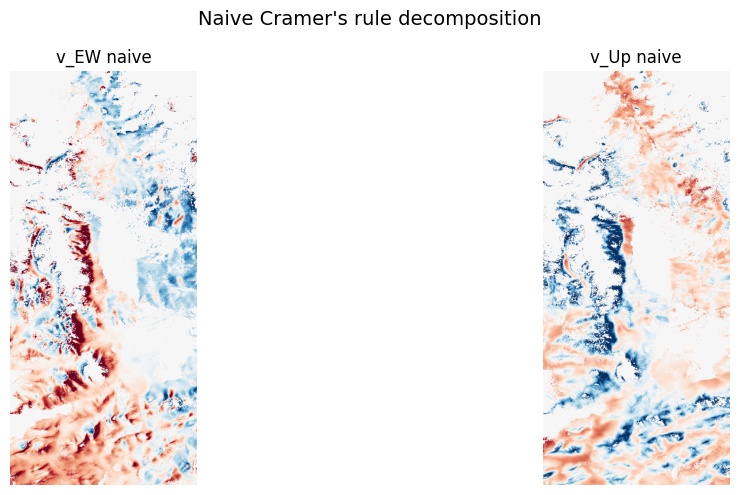

In [14]:
# Cell 3 - Naive decomposition (for comparison)
# Cramer's rule: pixel-by-pixel, no regularization
valid_naive = (mask_asc == 1) & (mask_desc == 1) & (np.abs(det_A) > 0.01)

v_EW_naive = np.zeros((ny, nx), dtype=np.float32)
v_Up_naive = np.zeros((ny, nx), dtype=np.float32)
v_EW_naive[valid_naive] = (vel_asc[valid_naive] * U_desc[valid_naive] -
                            vel_desc[valid_naive] * U_asc[valid_naive]) / det_A[valid_naive]
v_Up_naive[valid_naive] = (E_asc[valid_naive] * vel_desc[valid_naive] -
                            E_desc[valid_naive] * vel_asc[valid_naive]) / det_A[valid_naive]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ew_lim = np.percentile(np.abs(v_EW_naive[valid_naive]), 95)
up_lim = np.percentile(np.abs(v_Up_naive[valid_naive]), 95)
axes[0].imshow(v_EW_naive, origin='lower', cmap='RdBu_r', vmin=-ew_lim, vmax=ew_lim, rasterized=True)
axes[0].set_title('v_EW naive'); axes[0].axis('off')
axes[1].imshow(v_Up_naive, origin='lower', cmap='RdBu_r', vmin=-up_lim, vmax=up_lim, rasterized=True)
axes[1].set_title('v_Up naive'); axes[1].axis('off')
plt.suptitle('Naive Cramer\'s rule decomposition', fontsize=14)
plt.tight_layout(); plt.show()

In [15]:
# Cell 4 - Super-resolution grid setup
# The 0.83-pixel offset between asc/desc means they sample different sub-pixel positions.
# Together = 2x sampling density → CS can reconstruct at 2x resolution.
from scipy.ndimage import map_coordinates, zoom

SR_FACTOR = 2.01
ny_sr = int(round(ny * SR_FACTOR))   # the SR grid is an integer shape: zoom() rounds the same way,
nx_sr = int(round(nx * SR_FACTOR))   # and slices / np.zeros need ints (2.01 made these floats)

# Sub-pixel offset (desc relative to asc, in asc pixel units)
dy_offset = (float(clat_d) - float(clat_a)) / float(plat_a)  
dx_offset = (float(clon_d) - float(clon_a)) / float(plon_a)
print(f"Sub-pixel offset: dy={dy_offset:.4f}, dx={dx_offset:.4f} pixels")
print(f"SR grid: {ny_sr} x {nx_sr}")

# Measurement positions on SR grid
yy, xx = np.mgrid[0:ny, 0:nx]
sr_y_asc = (yy * SR_FACTOR).ravel().astype(np.float64)
sr_x_asc = (xx * SR_FACTOR).ravel().astype(np.float64)
sr_y_desc = (yy * SR_FACTOR + SR_FACTOR * dy_offset).ravel().astype(np.float64)
sr_x_desc = (xx * SR_FACTOR + SR_FACTOR * dx_offset).ravel().astype(np.float64)

# Flatten everything
d_a = vel_asc.ravel().astype(np.float64)
d_d = vel_desc.ravel().astype(np.float64)
w_a = ((coh_asc**2) * (mask_asc == 1)).ravel().astype(np.float64)
w_d = ((coh_desc**2) * (mask_desc == 1)).ravel().astype(np.float64)
Ea = E_asc.ravel().astype(np.float64)
Ua = U_asc.ravel().astype(np.float64)
Ed = E_desc.ravel().astype(np.float64)
Ud = U_desc.ravel().astype(np.float64)

print(f"Measurements: {2*ny*nx}, Unknowns: {2*ny_sr*nx_sr}")
print(f"Underdetermined ratio: {2*ny_sr*nx_sr/(2*ny*nx):.1f}x → CS appropriate")

Sub-pixel offset: dy=0.8334, dx=0.2200 pixels
SR grid: 2115 x 955
Measurements: 999400, Unknowns: 4039650
Underdetermined ratio: 4.0x → CS appropriate


In [16]:
# Cell 5 - Forward/adjoint operators
def forward_sr(v_ew, v_up):
    """Interpolate SR fields to measurement positions, combine with look vectors."""
    ew_a = map_coordinates(v_ew, [sr_y_asc, sr_x_asc], order=1, mode='nearest')
    up_a = map_coordinates(v_up, [sr_y_asc, sr_x_asc], order=1, mode='nearest')
    ew_d = map_coordinates(v_ew, [sr_y_desc, sr_x_desc], order=1, mode='nearest')
    up_d = map_coordinates(v_up, [sr_y_desc, sr_x_desc], order=1, mode='nearest')
    return Ea * ew_a + Ua * up_a, Ed * ew_d + Ud * up_d

def _splat(g, y, x, val):
    """Bilinear splat: the exact adjoint of map_coordinates(order=1, mode='nearest').
    Positions are clamped to the grid like the forward's edge mode, then each value is
    spread over its four neighbours with the bilinear weights."""
    y = np.clip(y, 0.0, g.shape[0] - 1.0)
    x = np.clip(x, 0.0, g.shape[1] - 1.0)
    y0 = np.floor(y).astype(int); x0 = np.floor(x).astype(int)
    y1 = np.minimum(y0 + 1, g.shape[0] - 1); x1 = np.minimum(x0 + 1, g.shape[1] - 1)
    wy = y - y0; wx = x - x0
    np.add.at(g, (y0, x0), val * (1 - wy) * (1 - wx))
    np.add.at(g, (y0, x1), val * (1 - wy) * wx)
    np.add.at(g, (y1, x0), val * wy * (1 - wx))
    np.add.at(g, (y1, x1), val * wy * wx)

def adjoint_sr(r_a, r_d):
    """Splat weighted residuals back to the SR grid (bilinear, so <A x, r> = <x, A^T r>;
    a nearest-pixel splat is not the adjoint once SR_FACTOR puts samples off the grid,
    and FISTA diverges on the mismatch)."""
    g_ew = np.zeros((ny_sr, nx_sr))
    g_up = np.zeros((ny_sr, nx_sr))
    _splat(g_ew, sr_y_asc, sr_x_asc, Ea * r_a)
    _splat(g_up, sr_y_asc, sr_x_asc, Ua * r_a)
    _splat(g_ew, sr_y_desc, sr_x_desc, Ed * r_d)
    _splat(g_up, sr_y_desc, sr_x_desc, Ud * r_d)
    return g_ew, g_up

def grad_sr(v_ew, v_up):
    pa, pd = forward_sr(v_ew, v_up)
    return adjoint_sr(w_a * (pa - d_a), w_d * (pd - d_d))

def cost_sr(v_ew, v_up):
    pa, pd = forward_sr(v_ew, v_up)
    return 0.5*np.sum(w_a*(pa-d_a)**2) + 0.5*np.sum(w_d*(pd-d_d)**2)

print("Operators ready.")

Operators ready.


In [17]:
# Cell 6 - FISTA + cycle-spinning SR decomposition
WAVELET = 'coif6'
LEVEL = 8              # 5 levels covers features up to 32px. Higher = slower, diminishing returns
N_ITER = 100

# Auto-lambda
noise_ew = np.std(v_EW_naive[(coh_asc<0.3) & valid_naive]) if ((coh_asc<0.3) & valid_naive).any() else 5.0
noise_up = np.std(v_Up_naive[(coh_asc<0.3) & valid_naive]) if ((coh_asc<0.3) & valid_naive).any() else 5.0
LAM_EW = .2 #noise_ew * np.sqrt(2*np.log(ny_sr*nx_sr)) * 0.2
LAM_UP = .2 #noise_up * np.sqrt(2*np.log(ny_sr*nx_sr)) * 0.2

print(f"LEVEL={LEVEL}, noise: EW={noise_ew:.2f} Up={noise_up:.2f}")
print(f"Lambda: EW={LAM_EW:.2f}, Up={LAM_UP:.2f}")

def cs_prox(image, lam, rng):
    """Cycle-spinning DWT soft-threshold with reflect padding.

    The shift is a roll of the whole reflect-padded frame and is undone by the opposite
    roll before the centre crop, so at lam = 0 the call is the identity. Shifting by
    slicing and undoing it by re-padding the output is not: it replaces a border strip
    of width |shift| by a mirror of interior rows on every call, and FISTA then blows
    up along the borders."""
    NY, NX = image.shape
    s = min(2**LEVEL, 32)  # pad at most 32px for cycle spinning shift
    dy, dx = rng.integers(-s, s+1), rng.integers(-s, s+1)
    padded = np.pad(image, s, mode='reflect')
    rolled = np.roll(padded, (dy, dx), axis=(0, 1))
    c = pywt.wavedec2(rolled, WAVELET, level=LEVEL, mode='reflect')
    c_t = [c[0]] + [tuple(pywt.threshold(d, lam, 'soft') for d in lev) for lev in c[1:]]
    out = pywt.waverec2(c_t, WAVELET, mode='reflect')[:rolled.shape[0], :rolled.shape[1]]
    return np.roll(out, (-dy, -dx), axis=(0, 1))[s:s+NY, s:s+NX]

# Init from upsampled naive
v_ew = zoom(v_EW_naive.astype(np.float64), SR_FACTOR, order=1)[:ny_sr, :nx_sr]
v_up = zoom(v_Up_naive.astype(np.float64), SR_FACTOR, order=1)[:ny_sr, :nx_sr]
z_ew, z_up = v_ew.copy(), v_up.copy()
t, step = 1.0, 0.3
rng = np.random.default_rng(42)
costs = []

print(f"Running FISTA: {N_ITER} iters, {WAVELET}, level={LEVEL}")
for k in range(N_ITER):
    ge, gu = grad_sr(z_ew, z_up)
    v_ew_new = cs_prox(z_ew - step*ge, LAM_EW*step, rng)
    v_up_new = cs_prox(z_up - step*gu, LAM_UP*step, rng)
    t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
    z_ew = v_ew_new + (t-1)/t_new * (v_ew_new - v_ew)
    z_up = v_up_new + (t-1)/t_new * (v_up_new - v_up)
    v_ew, v_up = v_ew_new, v_up_new
    t = t_new
    c = cost_sr(v_ew, v_up)
    costs.append(c)
    if k % 25 == 0 or k == N_ITER-1:
        print(f"  {k:3d}: cost={c:.1f}")

v_EW_sr = v_ew.astype(np.float32)
v_Up_sr = v_up.astype(np.float32)
print(f"Done. EW:[{v_EW_sr.min():.1f},{v_EW_sr.max():.1f}], Up:[{v_Up_sr.min():.1f},{v_Up_sr.max():.1f}]")

LEVEL=8, noise: EW=1.32 Up=1.33
Lambda: EW=0.20, Up=0.20
Running FISTA: 100 iters, coif6, level=8
    0: cost=233350.1
   25: cost=31239.0
   50: cost=23632.1
   75: cost=23059.0
   99: cost=23272.4
Done. EW:[-16.2,18.5], Up:[-23.8,16.7]


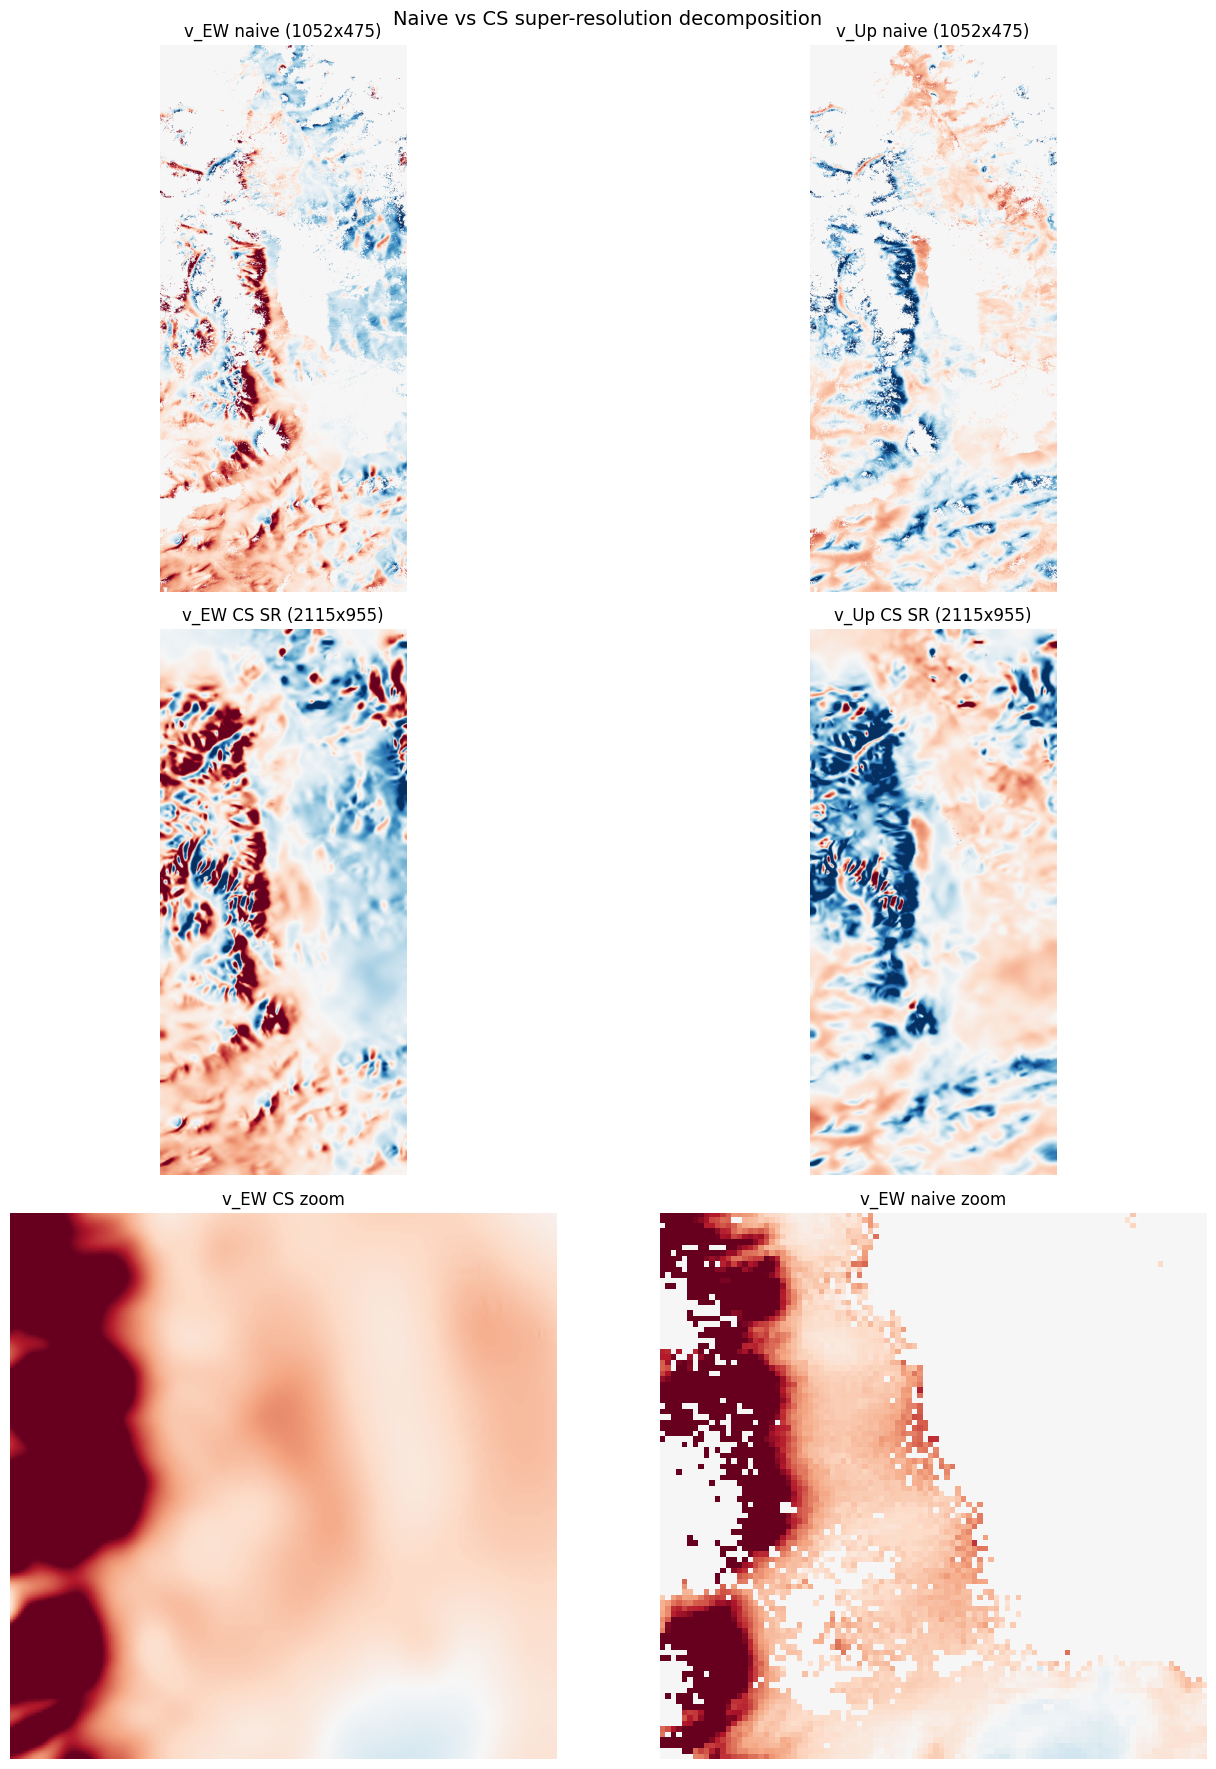

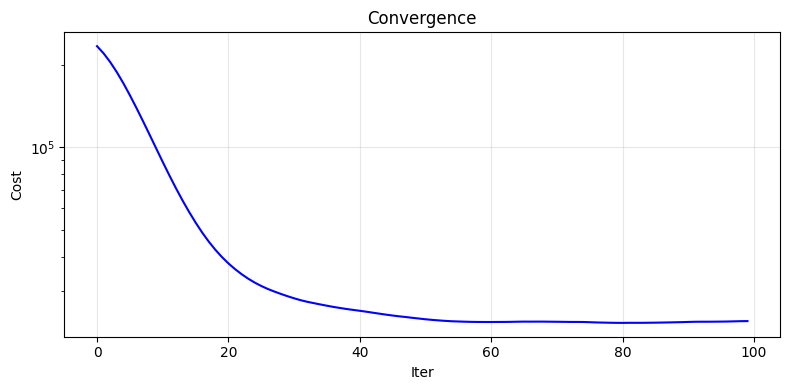

In [18]:
# Cell 7 - Compare naive vs CS super-resolution
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
ew_lim = np.percentile(np.abs(v_EW_sr), 95)
up_lim = np.percentile(np.abs(v_Up_sr), 95)

axes[0,0].imshow(v_EW_naive, origin='lower', cmap='RdBu_r', vmin=-ew_lim, vmax=ew_lim, rasterized=True)
axes[0,0].set_title(f'v_EW naive ({ny}x{nx})'); axes[0,0].axis('off')
axes[0,1].imshow(v_Up_naive, origin='lower', cmap='RdBu_r', vmin=-up_lim, vmax=up_lim, rasterized=True)
axes[0,1].set_title(f'v_Up naive ({ny}x{nx})'); axes[0,1].axis('off')

axes[1,0].imshow(v_EW_sr, origin='lower', cmap='RdBu_r', vmin=-ew_lim, vmax=ew_lim, rasterized=True)
axes[1,0].set_title(f'v_EW CS SR ({ny_sr}x{nx_sr})'); axes[1,0].axis('off')
axes[1,1].imshow(v_Up_sr, origin='lower', cmap='RdBu_r', vmin=-up_lim, vmax=up_lim, rasterized=True)
axes[1,1].set_title(f'v_Up CS SR ({ny_sr}x{nx_sr})'); axes[1,1].axis('off')

# Zoom center
cy, cx, w = ny//2, nx//2, 50
axes[2,0].imshow(v_EW_sr[cy*2-w*2:cy*2+w*2, cx*2-w*2:cx*2+w*2],
                 origin='lower', cmap='RdBu_r', vmin=-ew_lim, vmax=ew_lim, rasterized=True)
axes[2,0].set_title('v_EW CS zoom'); axes[2,0].axis('off')
axes[2,1].imshow(v_EW_naive[cy-w:cy+w, cx-w:cx+w],
                 origin='lower', cmap='RdBu_r', vmin=-ew_lim, vmax=ew_lim, rasterized=True)
axes[2,1].set_title('v_EW naive zoom'); axes[2,1].axis('off')

plt.suptitle('Naive vs CS super-resolution decomposition', fontsize=14)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(costs, 'b-'); ax.set(xlabel='Iter', ylabel='Cost'); ax.set_yscale('log')
ax.grid(True, alpha=0.3); ax.set_title('Convergence'); plt.tight_layout(); plt.show()

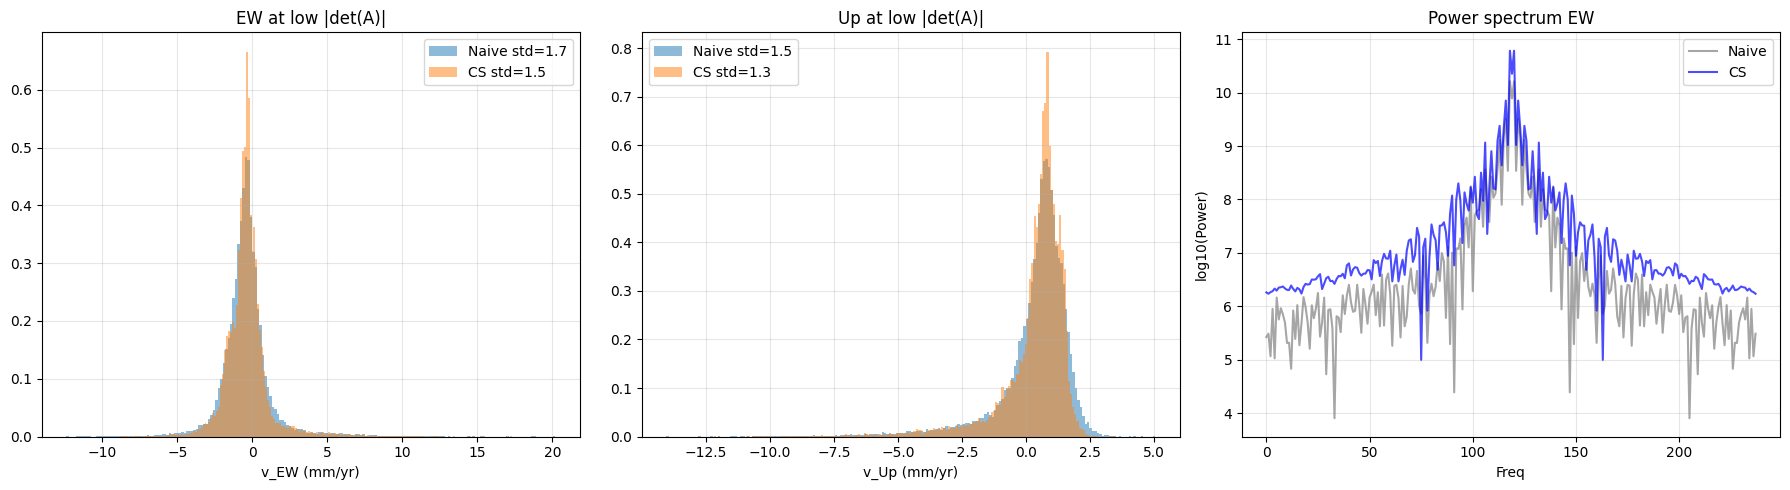

In [19]:
# Cell 8 - Noise diagnostics
def to_orig(v):
    """The SR field read at the ascending measurement positions: the original grid.
    A stride only works for an integer SR_FACTOR; this is exact for integers and right
    for 2.01, where the original pixels sit between SR pixels."""
    return map_coordinates(np.asarray(v, dtype=np.float64), [sr_y_asc, sr_x_asc],
                           order=1, mode='nearest').reshape(ny, nx)

v_ew_orig = to_orig(v_EW_sr)
v_up_orig = to_orig(v_Up_sr)

det_A = E_asc * U_desc - U_asc * E_desc
low_det = np.abs(det_A) < np.percentile(np.abs(det_A), 25)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (naive, cs, label) in zip(axes[:2], 
    [(v_EW_naive, v_ew_orig, 'EW'), (v_Up_naive, v_up_orig, 'Up')]):
    m = low_det & valid_naive
    ax.hist(naive[m].ravel(), bins=200, alpha=0.5, label=f'Naive std={naive[m].std():.1f}', density=True)
    ax.hist(cs[m].ravel(), bins=200, alpha=0.5, label=f'CS std={cs[m].std():.1f}', density=True)
    ax.set(xlabel=f'v_{label} (mm/yr)', title=f'{label} at low |det(A)|')
    ax.legend(); ax.grid(True, alpha=0.3)

# Power spectrum
from numpy.fft import fft2, fftshift
ps_n = np.log10(np.abs(fftshift(fft2(v_EW_naive)))**2 + 1)
ps_c = np.log10(np.abs(fftshift(fft2(v_ew_orig)))**2 + 1)
axes[2].plot(ps_n[ny//2, nx//4:3*nx//4], 'gray', alpha=0.7, label='Naive')
axes[2].plot(ps_c[ny//2, nx//4:3*nx//4], 'b', alpha=0.7, label='CS')
axes[2].set(xlabel='Freq', ylabel='log10(Power)', title='Power spectrum EW')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Testing 7 wavelets, 75 iters each...
  db2... cost=153271.7, noise_red=1.59, hf=0.001, sparse=0.034, autocorr=0.926, time=25s
  db4... cost=139809.7, noise_red=1.53, hf=0.000, sparse=0.033, autocorr=0.921, time=26s
  sym4... cost=137000.1, noise_red=1.51, hf=0.000, sparse=0.031, autocorr=0.919, time=24s
  sym6... cost=134936.3, noise_red=1.49, hf=0.000, sparse=0.032, autocorr=0.918, time=26s
  sym8... cost=134213.0, noise_red=1.49, hf=0.000, sparse=0.034, autocorr=0.918, time=28s
  coif2... cost=136605.0, noise_red=1.51, hf=0.000, sparse=0.031, autocorr=0.919, time=26s
  coif3... cost=133761.6, noise_red=1.49, hf=0.000, sparse=0.033, autocorr=0.918, time=28s

 Wavelet |      RMS | NoiseRed | HF ratio | Sparsity | AutoCorr |   Time
------------------------------------------------------------------------
     db2 |     0.50 |     1.59 |   0.0014 |   0.0343 |   0.9265 |    25s
     db4 |     0.48 |     1.53 |   0.0003 |   0.0330 |   0.9206 |    26s
    sym4 |     0.48 |     1.51 |   0.000

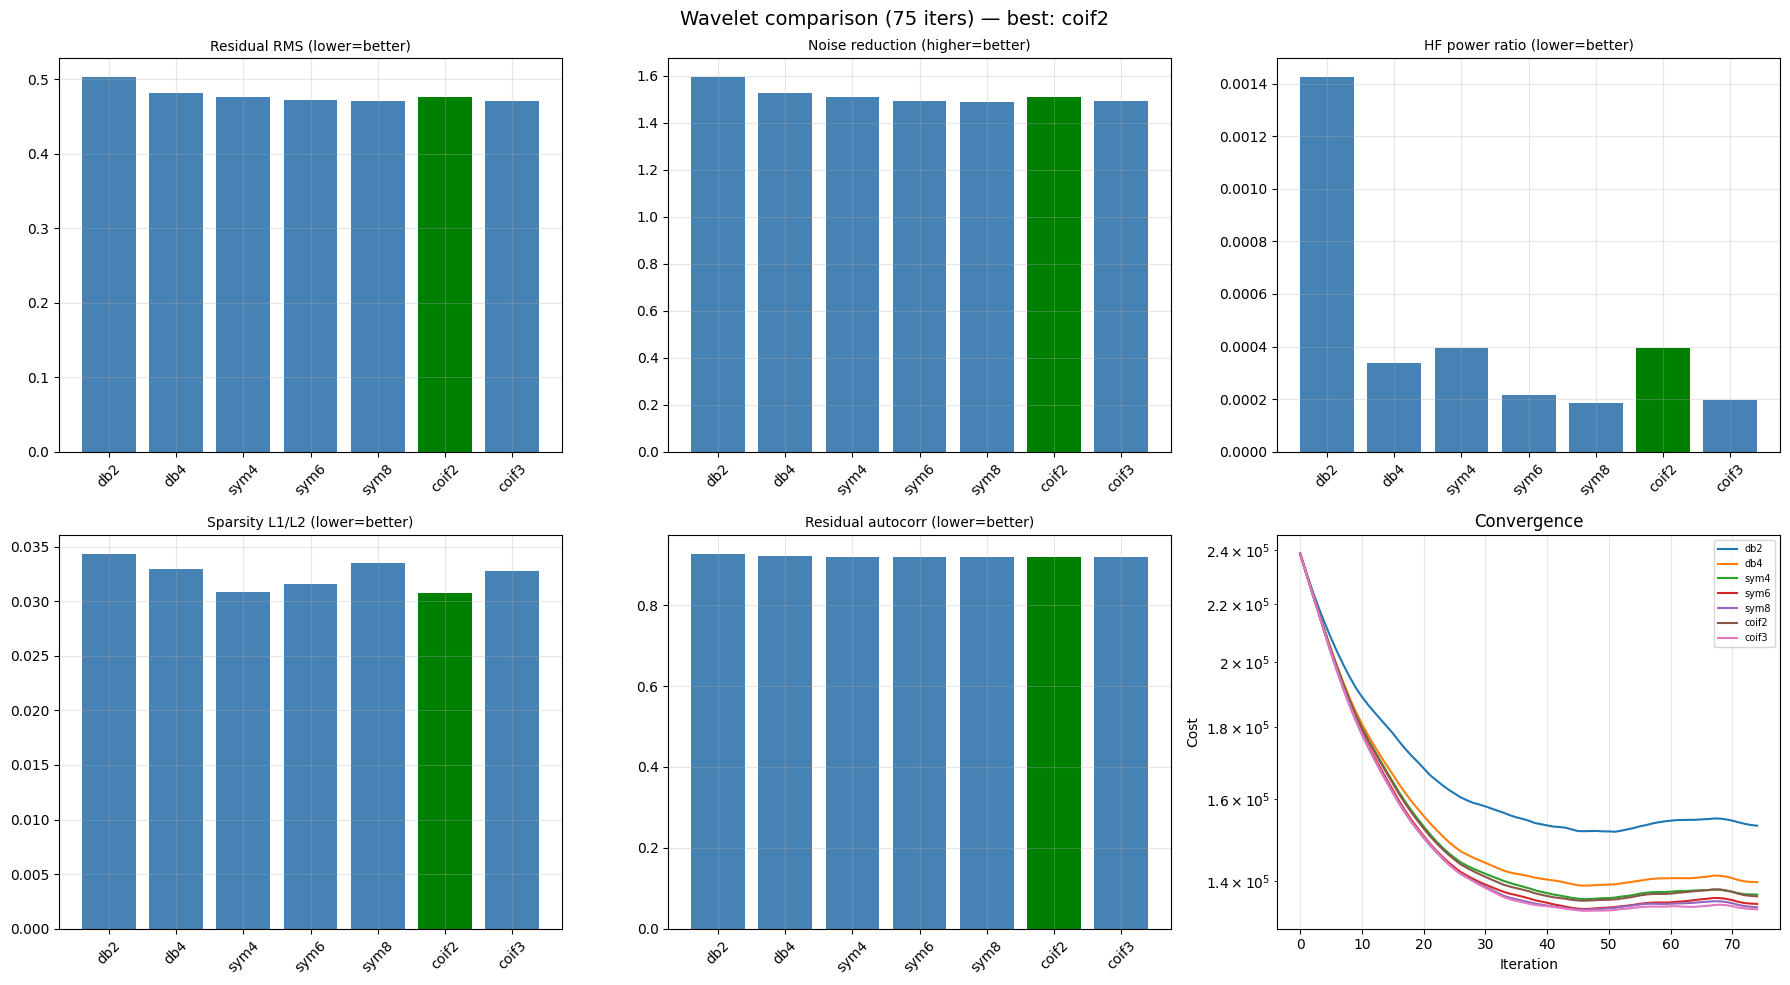

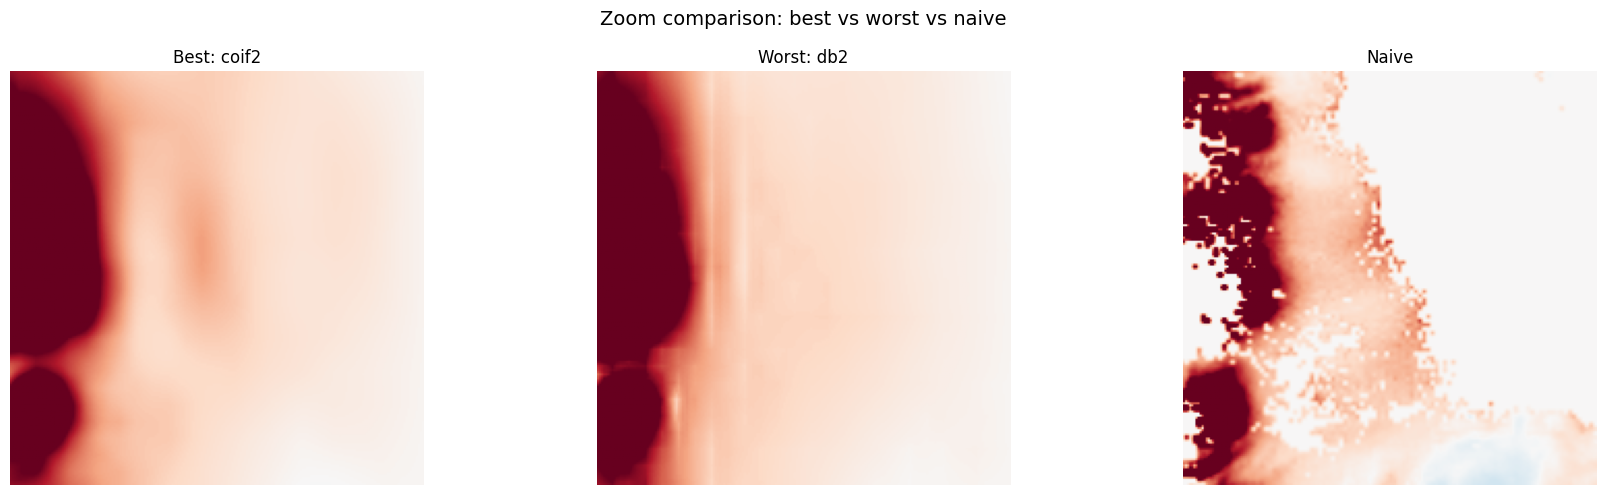

In [20]:
# Cell 8b - Wavelet comparison: run multiple wavelets, compare metrics
if 'to_orig' not in globals():
    def to_orig(v):
        """The SR field read at the ascending measurement positions: the original grid.
        A stride only works for an integer SR_FACTOR; this is exact for integers and right
        for 2.01, where the original pixels sit between SR pixels."""
        return map_coordinates(np.asarray(v, dtype=np.float64), [sr_y_asc, sr_x_asc],
                               order=1, mode='nearest').reshape(ny, nx)

import time
from scipy.ndimage import zoom as scipy_zoom
from numpy.fft import fft2, fftshift

WAVELETS_TEST = ['db2', 'db4', 'sym4', 'sym6', 'sym8', 'coif2', 'coif3']
N_ITER_CMP = 75  # fewer iters for speed
STEP_CMP = 0.3

det_A = E_asc * U_desc - U_asc * E_desc
low_det = np.abs(det_A) < np.percentile(np.abs(det_A), 25)
valid_m = (mask_asc == 1) & (mask_desc == 1)

def run_fista_wavelet(wav_name, n_iter):
    """Run FISTA with a specific wavelet, return SR result + cost history."""
    lev = min(8, int(np.log2(min(ny_sr, nx_sr))))
    
    # Auto-lambda for this wavelet
    lam_ew = noise_ew * np.sqrt(2*np.log(ny_sr*nx_sr)) * 0.2
    lam_up = noise_up * np.sqrt(2*np.log(ny_sr*nx_sr)) * 0.2
    
    def prox(image, lam, rng):
        s = 2**lev
        dy, dx = rng.integers(-s, s+1), rng.integers(-s, s+1)
        shifted = np.roll(np.roll(image, dy, 0), dx, 1)
        c = pywt.wavedec2(shifted, wav_name, level=lev)
        c_t = [c[0]] + [tuple(pywt.threshold(d, lam, 'soft') for d in l) for l in c[1:]]
        out = pywt.waverec2(c_t, wav_name)[:image.shape[0], :image.shape[1]]
        return np.roll(np.roll(out, -dy, 0), -dx, 1)
    
    vew = scipy_zoom(v_EW_naive.astype(np.float64), SR_FACTOR, order=1)[:ny_sr, :nx_sr]
    vup = scipy_zoom(v_Up_naive.astype(np.float64), SR_FACTOR, order=1)[:ny_sr, :nx_sr]
    zew, zup = vew.copy(), vup.copy()
    t_m, rng_m = 1.0, np.random.default_rng(42)
    cs = []
    
    for k in range(n_iter):
        ge, gu = grad_sr(zew, zup)
        vew_n = prox(zew - STEP_CMP*ge, lam_ew*STEP_CMP, rng_m)
        vup_n = prox(zup - STEP_CMP*gu, lam_up*STEP_CMP, rng_m)
        t_n = (1 + np.sqrt(1 + 4*t_m**2)) / 2
        zew = vew_n + (t_m-1)/t_n * (vew_n - vew)
        zup = vup_n + (t_m-1)/t_n * (vup_n - vup)
        vew, vup = vew_n, vup_n
        t_m = t_n
        cs.append(cost_sr(vew, vup))
    
    return vew.astype(np.float32), vup.astype(np.float32), cs

def compute_metrics(vew_sr, vup_sr, wav_name):
    """Compute quality metrics for a CS result."""
    # Downsample to original grid
    vew_o = to_orig(vew_sr)
    vup_o = to_orig(vup_sr)
    
    # 1. Data fidelity (residual RMS)
    pa, pd = forward_sr(vew_sr.astype(np.float64), vup_sr.astype(np.float64))
    rms_asc = np.sqrt(np.mean(w_a * (pa - d_a)**2))
    rms_desc = np.sqrt(np.mean(w_d * (pd - d_d)**2))
    
    # 2. Noise reduction at low det(A)
    m = low_det & valid_m
    nr_ew = v_EW_naive[m].std() / (vew_o[m].std() + 1e-10)
    nr_up = v_Up_naive[m].std() / (vup_o[m].std() + 1e-10)
    
    # 3. High-frequency power ratio
    ps_naive = np.abs(fftshift(fft2(v_EW_naive)))**2
    ps_cs = np.abs(fftshift(fft2(vew_o)))**2
    ky, kx = np.mgrid[-ny//2:ny//2, -nx//2:nx//2]
    kr = np.sqrt(kx**2 + ky**2)
    k_max = min(ny, nx) // 2
    hf_mask = kr > k_max * 0.75  # top 25% frequencies
    hf_ratio = ps_cs[hf_mask].mean() / (ps_naive[hf_mask].mean() + 1e-10)
    
    # 4. Sparsity (L1/L2 of wavelet coefficients)
    lev = min(8, int(np.log2(min(ny_sr, nx_sr))))
    coeffs = pywt.wavedec2(vew_sr, wav_name, level=lev)
    all_c = np.concatenate([c.ravel() for detail in coeffs[1:] for c in detail])
    l1 = np.sum(np.abs(all_c))
    l2 = np.sqrt(np.sum(all_c**2))
    sparsity = l1 / (l2 * np.sqrt(len(all_c)) + 1e-10)  # normalized, 0=sparse, 1=dense
    
    # 5. Residual autocorrelation at lag 1
    res = (pa - d_a).reshape(ny, nx)
    res_shift = np.roll(res, 1, axis=1)
    v_res = valid_m.ravel().reshape(ny, nx)
    ac = np.corrcoef(res[v_res].ravel(), res_shift[v_res].ravel())[0, 1]
    
    return {
        'rms': (rms_asc + rms_desc) / 2,
        'noise_red': (nr_ew + nr_up) / 2,
        'hf_ratio': hf_ratio,
        'sparsity': sparsity,
        'autocorr': abs(ac),
    }

# Run comparison
print(f"Testing {len(WAVELETS_TEST)} wavelets, {N_ITER_CMP} iters each...")
results = {}
for wav in WAVELETS_TEST:
    t0 = time.time()
    print(f"  {wav}...", end=" ", flush=True)
    vew, vup, costs = run_fista_wavelet(wav, N_ITER_CMP)
    metrics = compute_metrics(vew, vup, wav)
    metrics['final_cost'] = costs[-1]
    metrics['time'] = time.time() - t0
    metrics['vew'] = vew  # store for visualization
    metrics['vup'] = vup
    metrics['costs'] = costs
    results[wav] = metrics
    print(f"cost={costs[-1]:.1f}, noise_red={metrics['noise_red']:.2f}, "
          f"hf={metrics['hf_ratio']:.3f}, sparse={metrics['sparsity']:.3f}, "
          f"autocorr={metrics['autocorr']:.3f}, time={metrics['time']:.0f}s")

# Display comparison table
print(f"\n{'Wavelet':>8} | {'RMS':>8} | {'NoiseRed':>8} | {'HF ratio':>8} | {'Sparsity':>8} | {'AutoCorr':>8} | {'Time':>6}")
print("-" * 72)
for wav in WAVELETS_TEST:
    m = results[wav]
    print(f"{wav:>8} | {m['rms']:8.2f} | {m['noise_red']:8.2f} | {m['hf_ratio']:8.4f} | {m['sparsity']:8.4f} | {m['autocorr']:8.4f} | {m['time']:5.0f}s")

# Rank: lower RMS + higher noise_red + lower HF + lower sparsity + lower autocorr = better
# Normalize each metric to [0,1] and compute weighted score
metrics_names = ['rms', 'hf_ratio', 'sparsity', 'autocorr']  # lower is better
metrics_inv = ['noise_red']  # higher is better

scores = {}
for wav in WAVELETS_TEST:
    score = 0
    for mn in metrics_names:
        vals = [results[w][mn] for w in WAVELETS_TEST]
        score += (results[wav][mn] - min(vals)) / (max(vals) - min(vals) + 1e-10)
    for mn in metrics_inv:
        vals = [results[w][mn] for w in WAVELETS_TEST]
        score += 1 - (results[wav][mn] - min(vals)) / (max(vals) - min(vals) + 1e-10)
    scores[wav] = score

best = min(scores, key=scores.get)
print(f"\nBest wavelet: {best} (score={scores[best]:.3f})")

# Bar charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metric_info = [
    ('rms', 'Residual RMS (lower=better)', False),
    ('noise_red', 'Noise reduction (higher=better)', True),
    ('hf_ratio', 'HF power ratio (lower=better)', False),
    ('sparsity', 'Sparsity L1/L2 (lower=better)', False),
    ('autocorr', 'Residual autocorr (lower=better)', False),
]

for ax, (mn, title, higher_better) in zip(axes.flat[:5], metric_info):
    vals = [results[w][mn] for w in WAVELETS_TEST]
    colors = ['green' if w == best else 'steelblue' for w in WAVELETS_TEST]
    ax.bar(WAVELETS_TEST, vals, color=colors)
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

# Convergence curves
ax6 = axes[1, 2]
for wav in WAVELETS_TEST:
    ax6.plot(results[wav]['costs'], label=wav, lw=1.5)
ax6.set(xlabel='Iteration', ylabel='Cost', title='Convergence')
ax6.set_yscale('log'); ax6.legend(fontsize=7); ax6.grid(True, alpha=0.3)

plt.suptitle(f'Wavelet comparison ({N_ITER_CMP} iters) — best: {best}', fontsize=14)
plt.tight_layout(); plt.show()

# Zoom comparison: best vs worst
worst = max(scores, key=scores.get)
cy, cx, w = ny_sr//2, nx_sr//2, 100
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (wav, title) in zip(axes, [(best, f'Best: {best}'), (worst, f'Worst: {worst}'), (None, 'Naive')]):
    if wav:
        img = results[wav]['vew'][cy-w:cy+w, cx-w:cx+w]
    else:
        img = scipy_zoom(v_EW_naive.astype(np.float64), SR_FACTOR, order=1)[cy-w:cy+w, cx-w:cx+w]
    ax.imshow(img, origin='lower', cmap='RdBu_r', vmin=-ew_lim, vmax=ew_lim, rasterized=True)
    ax.set_title(title); ax.axis('off')
plt.suptitle('Zoom comparison: best vs worst vs naive', fontsize=14)
plt.tight_layout(); plt.show()


In [20]:
# Cell 9 - Save
out = '/Users/amasaryk/projects/Creep/wavelet/decomposed_cs_sr.npz'
np.savez(out, v_EW_sr=v_EW_sr, v_Up_sr=v_Up_sr,
         v_EW_naive=v_EW_naive, v_Up_naive=v_Up_naive,
         SR_FACTOR=SR_FACTOR, ny_orig=ny, nx_orig=nx,
         coh_asc=coh_asc, coh_desc=coh_desc, hgt=hgt,
         dy_offset=dy_offset, dx_offset=dx_offset)
print(f"Saved to {out}")
print(f"  v_EW_sr: {v_EW_sr.shape}, v_Up_sr: {v_Up_sr.shape}")
print(f"Load in WTMM notebook:")
print(f"  d = np.load('{out}')")
print(f"  v_EW = d['v_EW_sr']  # or d['v_EW_sr'][::2,::2] for original res")

Saved to /Users/amasaryk/projects/Creep/wavelet/decomposed_cs_sr.npz
  v_EW_sr: (2104, 950), v_Up_sr: (2104, 950)
Load in WTMM notebook:
  d = np.load('/Users/amasaryk/projects/Creep/wavelet/decomposed_cs_sr.npz')
  v_EW = d['v_EW_sr']  # or d['v_EW_sr'][::2,::2] for original res
